# PBC vs open-z (Arm B): does electrostatic z-periodicity drive the localised-jellium energy oscillation?

**The question.** Every energy-oscillation run to date (diagnosis + cap_fix, slab_n52 lineage) used a **fully periodic cell** (periodicity 3). After the period-lengthening re-reading of cap_fix (the E_total minimum drifts later along the 'improvement' ladder — 21.6 → 27.8 → ~33 → 36.4 → >48 a.u. — and every sufficiently long two-sided run turns up), the user hypothesised the periodic boundary plays a causal role. 'PBC vs open-z' splits into two channels: **Arm A** (density recirculation — the FFT wavefunction always wraps; only absorbers stop it; not run) and **Arm B** (electrostatic periodicity — Hartree images along z + charged-cell G=0 convention; switchable via INQ `periodicity(2)`, slab-truncated Poisson). This notebook reports **Arm B**: three matched p2/p3 witness pairs, identical in every respect except the Poisson convention (and the correspondingly re-converged ground state).

Campaign: `docs/campaigns/localised_jellium/pbc-open-z-oscillation.md` · diagnosis: `hypotheses/energy_oscillation_diagnosis/` · setup search: `hypotheses/cap_fix/`

## Conventions and symbols

Atomic units throughout (ħ = 1); energies reported in eV via 1 Ha = 27.211386 eV. All comparisons are **ΔE shapes only** — absolute energies differ between p2 and p3 by the charged-cell G=0 convention and must never be compared.

| symbol | meaning | unit |
|---|---|---|
| p3 | fully periodic cell (`.periodic()`, periodicity 3) — ALL prior runs | — |
| p2 | periodic x,y + open-z electrostatics (`periodicity(2)`, slab-truncated Poisson) | — |
| ΔE_total(t) | E_total(t) − E_total(0), the reported-ledger drift | eV |
| t_min | time of the ΔE_total minimum (the oscillation's first turn) | a.u. |
| drain | ΔE_total(t_min) — energy removed before the turn | eV |
| rise | ΔE_total(end) − ΔE_total(t_min) — the post-minimum artifact | eV |
| excursion | max(0, max_t ΔE_total) — climb above the t=0 reference | eV |
| noise floor | 0.1 eV (3× the worst clean-run rise; cap_fix contract) | eV |


## Simulation setup (fully reconstructable)

Identical to the cap_fix witness harness in everything except the two switched items (periodicity + matching GS):

- **Cell/grid:** 40×40×80 Bohr orthorhombic, dx = 0.333 Bohr; jellium slab background half-width 12.5 Bohr (25 Bohr thick), edge width 1.0 Bohr, n₀ = 1.30×10⁻³ a₀⁻³ (r_s ≈ 5.68), N = 52 electrons; LDA; Γ-only.
- **Dynamics:** ETRS, dt = 0.04 a.u.; 700 steps (t = 28) or 950 steps (t = 38); write_every = 5. Engine: inq-study (mass fork).
- **Projectile:** Gaussian WP σ = 1 Bohr, k₀ = 5.693, m_eff = 2.10, launched at z = −16.5 (identical in every run).
- **CAP configs (the three witnesses):** two-sided sin² bumps at ±32.5 (width 15) with η = −0.2 / −1.0, and the wrap-around cos² bump peaking at the boundary (width 40) with η = −2.0.
- **Ground states:** p3 runs load `shared_gs/slab_n52_L40x40x80_dx0p333` (the production GS); p2 runs load the freshly converged `shared_gs/slab_n52_L40x40x80_dx0p333_per2` (same SCF recipe, periodicity 2). Loading a p3 GS into a p2 run is forbidden — it is not an eigenstate of the p2 Hamiltonian and would inject a spurious t=0 kick.
- **GS gate (passed pre-RT):** interior n(z) on n₀; tail at the CAP footprint (|z| > 32.5) = 2.2×10⁻¹¹ a₀⁻³ — about six orders tighter than the p3 GS tail.


## Source files

| role | path |
|---|---|
| p2 GS producer | `ResearchProject/systems/localised_jellium/scripts/pbc_open_z/gs/run.cpp` |
| RT binary (EM_PERIODICITY knob) | `ResearchProject/systems/localised_jellium/scripts/cap_fix/run.cpp` |
| locked metric extractor | `ResearchProject/systems/localised_jellium/scripts/cap_fix/run_metrics.py` |
| orchestrator (one-GPU serial chain) | `ResearchProject/systems/localised_jellium/scripts/pbc_open_z/orchestrate.py` |
| auto comparison table | `ResearchProject/systems/localised_jellium/hypotheses/pbc_open_z/comparison.md` |
| this builder | `ResearchProject/systems/localised_jellium/hypotheses/pbc_open_z/build_pbc_open_z_report.py` |
| wrap CAP perturbation | `inq-stack/include/inqkit/perturbations/absorbing_wrap.hpp` |
| p2/p3 run data | `scripts/cap_fix/results/{p2_*, run01, run06, run11}/raw/observables/` |

*Density GIF note (no silent drops): the cap_fix harness disables VTI emission (`emit_raw_vti=false`; observables + charge ledger only), so no xz density GIFs exist for these runs. The per-run energetics panels below carry the per-run diagnostic role instead.*

In [1]:
import sys, os
sys.path.insert(0, '/local/data/public/skcb2/tddft/inq-stack/python')
import numpy as np
from IPython.display import Image, display
from inqview.visualisation import style
style.apply_theme()
SYS = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium'
print('theme applied; provenance root:', SYS)

theme applied; provenance root: /local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium


## The p2 ground state

Planar-averaged density profile: $\bar n(z) = \frac{1}{L_xL_y}\int n(x,y,z)\,dx\,dy$ — computed from the GS density VTI (loaded via the canonical `inqview.load_vti`; physical order, never fftshift). The CAP footprint (|z| > 25) and the gate threshold are marked; the open-z Poisson binds the density visibly tighter than p3 (tail 2.2×10⁻¹¹ vs ~10⁻⁵-scale at p3) — yet, as the results show, the oscillation persists, so the *static* GS tail is not the artifact's feeder.

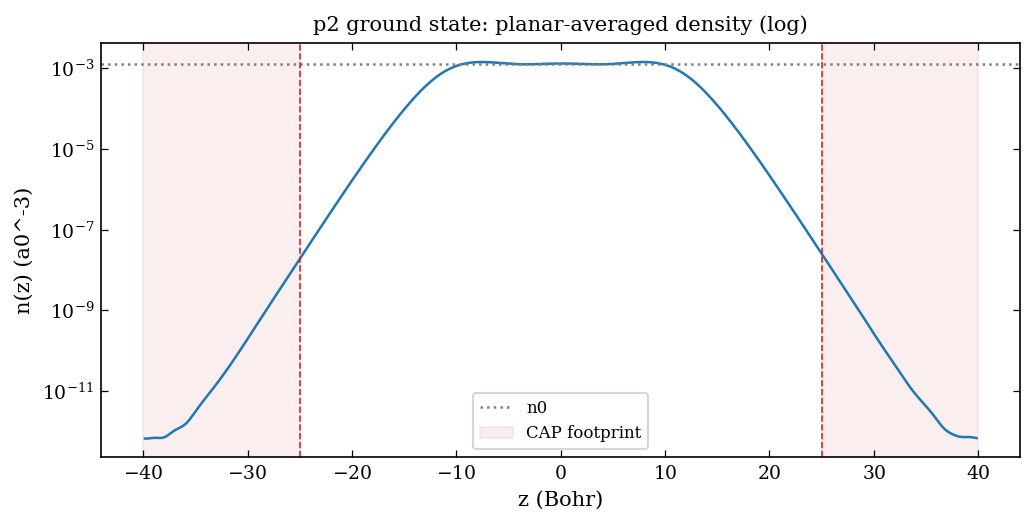

tail max at |z|>32.5: 2.17e-11 a0^-3


In [2]:
import matplotlib.pyplot as plt
from inqview import load_vti

os.makedirs("figs", exist_ok=True)
f = load_vti('/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/pbc_open_z/gs/results/density_gs/density_gs.vti', expect_centered_axis="z")
nz = f.data.mean(axis=(0, 1))
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogy(f.z, np.maximum(nz, 1e-16))
ax.axhline(1.30e-3, ls=":", color="tab:gray", label="n0")
for zc in (25, -25):
    ax.axvline(zc, ls="--", color="tab:red", lw=0.8)
ax.axvspan(25, 40, alpha=0.08, color="tab:red")
ax.axvspan(-40, -25, alpha=0.08, color="tab:red", label="CAP footprint")
ax.set_xlabel("z (Bohr)"); ax.set_ylabel("n(z) (a0^-3)")
ax.set_title("p2 ground state: planar-averaged density (log)")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("figs/p2_gs_nz.png", dpi=150); plt.show()
print(f"tail max at |z|>32.5: {nz[np.abs(f.z) > 32.5].max():.2e} a0^-3")


## Results — the three witness pairs

For each pair: the energy plot overlays $\Delta E_\mathrm{total}(t) = E_\mathrm{total}(t) - E_\mathrm{total}(0)$ (eV) for p2 (open-z electrostatics) and p3 (fully periodic), same axes, zero line marking the unphysical region; the minimum of each curve is dotted. The locked metrics (t_min, drain, rise, excursion) are printed per run.

### Pair 1: two-sided CAP, η=−0.2, 700 steps (t=28)

**Why this witness:** the fastest full-turn oscillation witness. p2 run `p2_two_eta0p2_700` vs p3 twin `run01_baseline_two_eta0p2`.

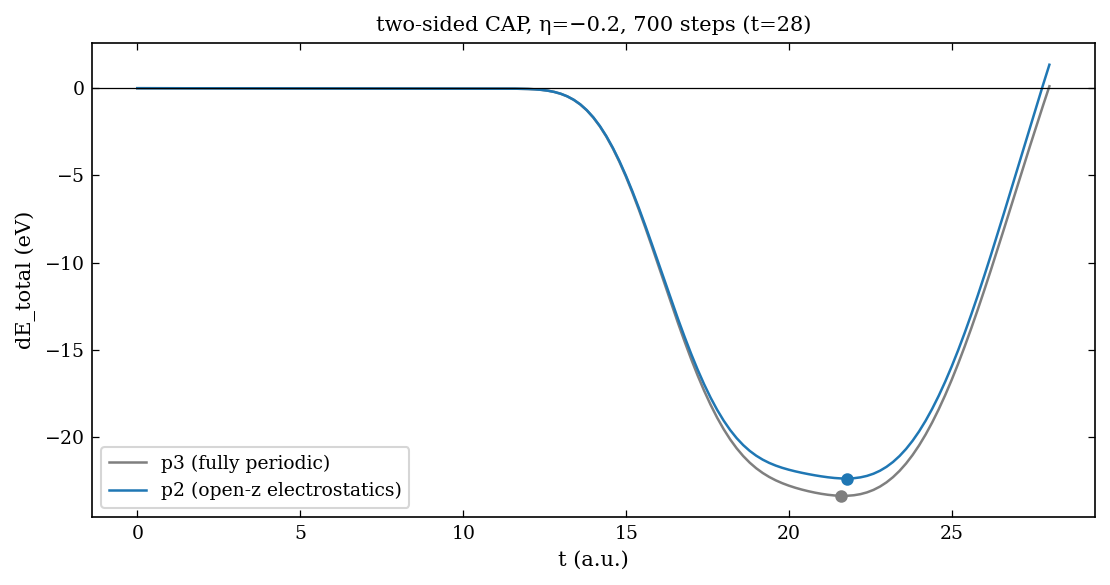

p2: t_min= 21.8  drain=  -22.39 eV  rise= +23.739 eV  excursion= +1.346 eV
p3: t_min= 21.6  drain=  -23.38 eV  rise= +23.495 eV  excursion= +0.110 eV


In [3]:
import pandas as pd
HA_EV = 27.211386
BASE = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/cap_fix/results'

def series(run):
    df = pd.read_csv(f"{BASE}/{run}/raw/observables/observables.csv")
    dE = (df.energy_total - df.energy_total.iloc[0]) * HA_EV
    return df.time_au.values, dE.values

def metrics(t, dE):
    im = int(np.argmin(dE))
    return dict(t_min=t[im], drain=dE[im], rise=dE[-1] - dE[im],
                excursion=max(0.0, dE.max()))

t2, e2 = series('p2_two_eta0p2_700')
t3, e3 = series('run01_baseline_two_eta0p2')
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(t3, e3, color="tab:gray", label="p3 (fully periodic)")
ax.plot(t2, e2, color="tab:blue", label="p2 (open-z electrostatics)")
for t, e, c in ((t3, e3, "tab:gray"), (t2, e2, "tab:blue")):
    im = int(np.argmin(e)); ax.plot(t[im], e[im], "o", color=c, ms=5)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("dE_total (eV)")
ax.set_title('two-sided CAP, η=−0.2, 700 steps (t=28)')
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig("figs/p2_two_eta0p2_700_pair.png", dpi=150); plt.show()
for tag, (t, e) in (("p2", (t2, e2)), ("p3", (t3, e3))):
    m = metrics(t, e)
    print(f"{tag}: t_min={m['t_min']:5.1f}  drain={m['drain']:+8.2f} eV  "
          f"rise={m['rise']:+8.3f} eV  excursion={m['excursion']:+7.3f} eV")


Per-run energetics of the new p2 run (`p2_two_eta0p2_700`): component drifts of the reported ledger — the norm-divided kinetic term (diagnosis Part II.4) should dominate any drain/rise, as it does at p3.

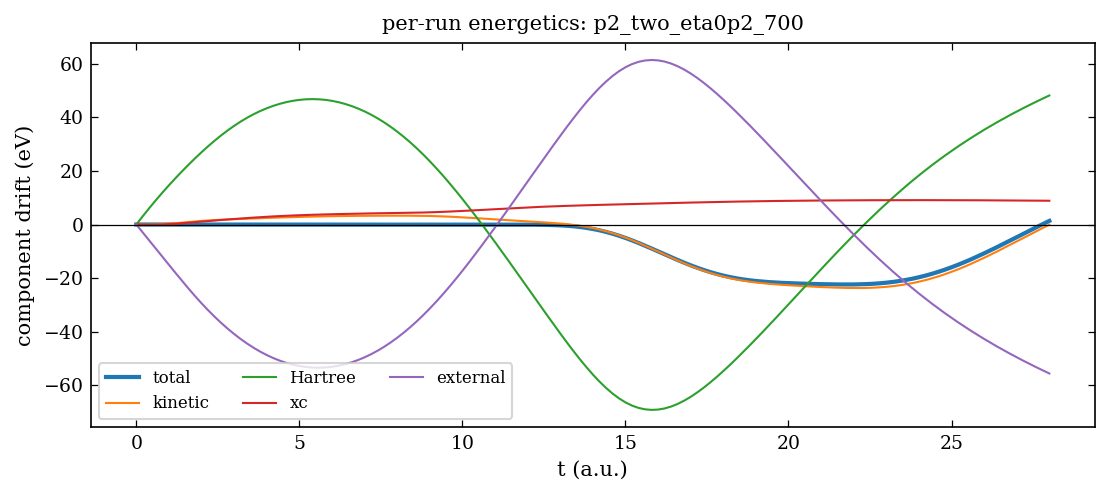

In [4]:
comps = [("energy_kinetic", "kinetic"), ("energy_hartree", "Hartree"),
         ("energy_xc", "xc"), ("energy_external", "external")]
df = pd.read_csv(f"{BASE}/p2_two_eta0p2_700/raw/observables/observables.csv")
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for c, lbl in [("energy_total", "total")] + comps:
    ax.plot(df.time_au, (df[c] - df[c].iloc[0]) * HA_EV, label=lbl,
            lw=2 if c == "energy_total" else 1)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("component drift (eV)")
ax.set_title("per-run energetics: p2_two_eta0p2_700")
ax.legend(fontsize=8, ncol=3)
fig.tight_layout(); fig.savefig("figs/p2_two_eta0p2_700_energetics.png", dpi=150); plt.show()


### Pair 2: two-sided CAP, η=−1.0, 950 steps (t=38; p3 twin partial to t=36)

**Why this witness:** the big above-zero riser (phase-0 regime). p2 run `p2_two_eta1p0_950` vs p3 twin `run06_poscontrol_eta1p0_950`.

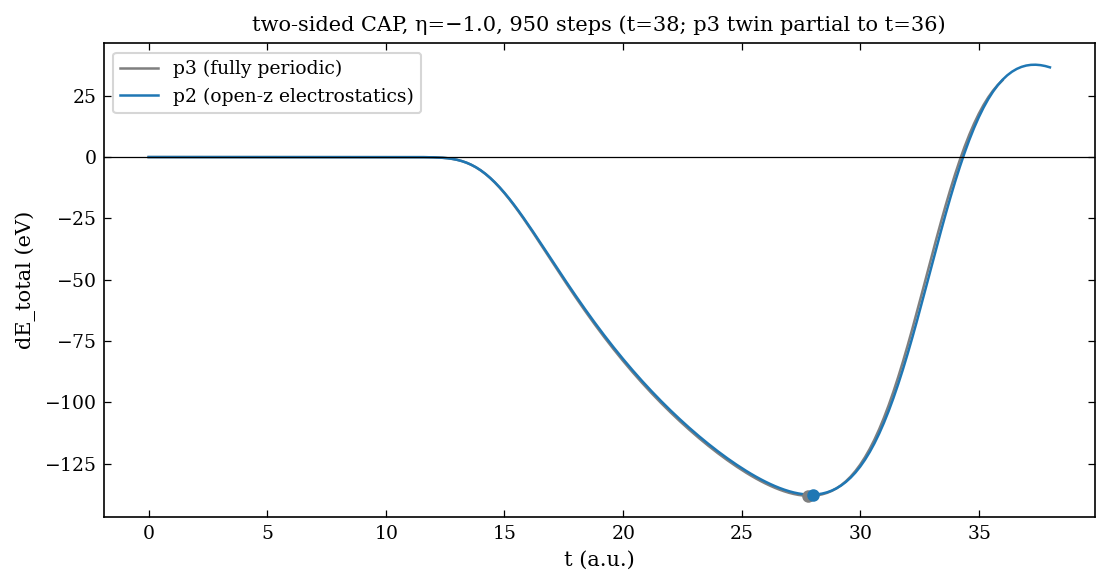

p2: t_min= 28.0  drain= -137.57 eV  rise=+174.131 eV  excursion=+37.623 eV
p3: t_min= 27.8  drain= -138.05 eV  rise=+169.324 eV  excursion=+31.272 eV


In [5]:
import pandas as pd
HA_EV = 27.211386
BASE = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/cap_fix/results'

def series(run):
    df = pd.read_csv(f"{BASE}/{run}/raw/observables/observables.csv")
    dE = (df.energy_total - df.energy_total.iloc[0]) * HA_EV
    return df.time_au.values, dE.values

def metrics(t, dE):
    im = int(np.argmin(dE))
    return dict(t_min=t[im], drain=dE[im], rise=dE[-1] - dE[im],
                excursion=max(0.0, dE.max()))

t2, e2 = series('p2_two_eta1p0_950')
t3, e3 = series('run06_poscontrol_eta1p0_950')
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(t3, e3, color="tab:gray", label="p3 (fully periodic)")
ax.plot(t2, e2, color="tab:blue", label="p2 (open-z electrostatics)")
for t, e, c in ((t3, e3, "tab:gray"), (t2, e2, "tab:blue")):
    im = int(np.argmin(e)); ax.plot(t[im], e[im], "o", color=c, ms=5)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("dE_total (eV)")
ax.set_title('two-sided CAP, η=−1.0, 950 steps (t=38; p3 twin partial to t=36)')
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig("figs/p2_two_eta1p0_950_pair.png", dpi=150); plt.show()
for tag, (t, e) in (("p2", (t2, e2)), ("p3", (t3, e3))):
    m = metrics(t, e)
    print(f"{tag}: t_min={m['t_min']:5.1f}  drain={m['drain']:+8.2f} eV  "
          f"rise={m['rise']:+8.3f} eV  excursion={m['excursion']:+7.3f} eV")


Per-run energetics of the new p2 run (`p2_two_eta1p0_950`): component drifts of the reported ledger — the norm-divided kinetic term (diagnosis Part II.4) should dominate any drain/rise, as it does at p3.

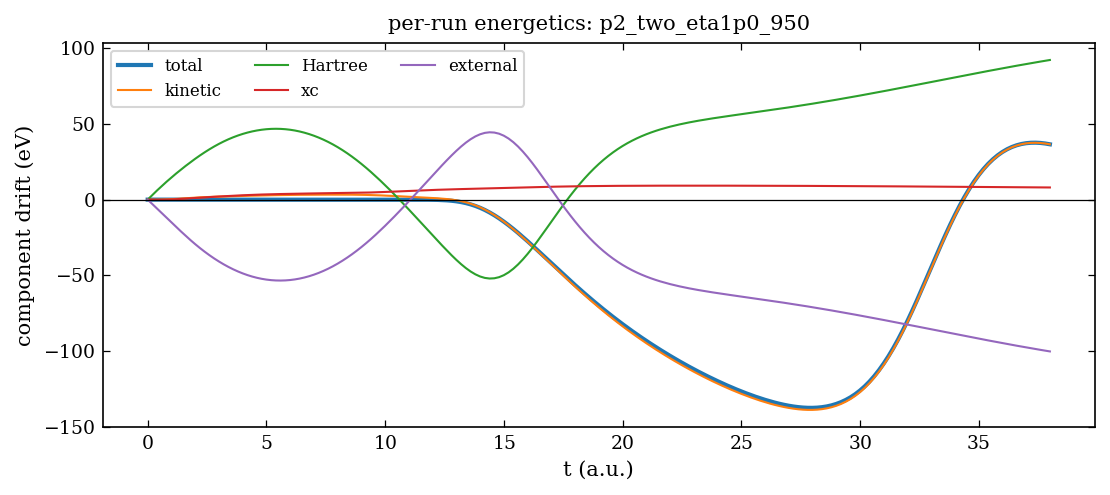

In [6]:
comps = [("energy_kinetic", "kinetic"), ("energy_hartree", "Hartree"),
         ("energy_xc", "xc"), ("energy_external", "external")]
df = pd.read_csv(f"{BASE}/p2_two_eta1p0_950/raw/observables/observables.csv")
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for c, lbl in [("energy_total", "total")] + comps:
    ax.plot(df.time_au, (df[c] - df[c].iloc[0]) * HA_EV, label=lbl,
            lw=2 if c == "energy_total" else 1)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("component drift (eV)")
ax.set_title("per-run energetics: p2_two_eta1p0_950")
ax.legend(fontsize=8, ncol=3)
fig.tight_layout(); fig.savefig("figs/p2_two_eta1p0_950_energetics.png", dpi=150); plt.show()


### Pair 3: wrap-around CAP, η=−2.0, width 40, 950 steps (t=38)

**Why this witness:** the cap_fix winner — does its cleanliness survive open-z?. p2 run `p2_wrap_eta2p0_w40_950` vs p3 twin `run11_wrap_eta2p0_w40_950`.

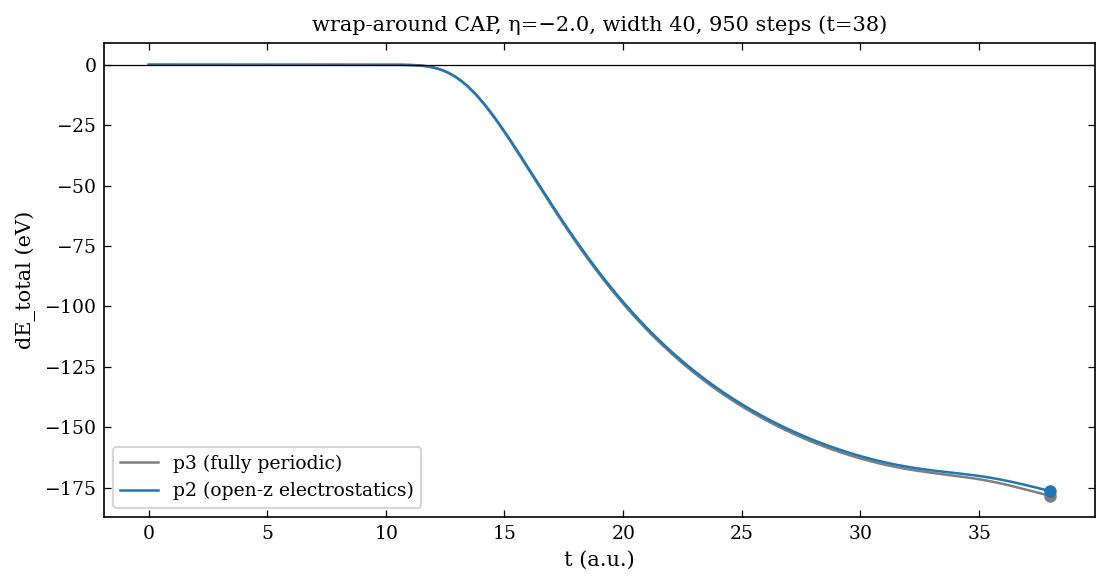

p2: t_min= 38.0  drain= -176.31 eV  rise=  +0.000 eV  excursion= +0.002 eV
p3: t_min= 38.0  drain= -178.31 eV  rise=  +0.000 eV  excursion= +0.000 eV


In [7]:
import pandas as pd
HA_EV = 27.211386
BASE = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/cap_fix/results'

def series(run):
    df = pd.read_csv(f"{BASE}/{run}/raw/observables/observables.csv")
    dE = (df.energy_total - df.energy_total.iloc[0]) * HA_EV
    return df.time_au.values, dE.values

def metrics(t, dE):
    im = int(np.argmin(dE))
    return dict(t_min=t[im], drain=dE[im], rise=dE[-1] - dE[im],
                excursion=max(0.0, dE.max()))

t2, e2 = series('p2_wrap_eta2p0_w40_950')
t3, e3 = series('run11_wrap_eta2p0_w40_950')
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(t3, e3, color="tab:gray", label="p3 (fully periodic)")
ax.plot(t2, e2, color="tab:blue", label="p2 (open-z electrostatics)")
for t, e, c in ((t3, e3, "tab:gray"), (t2, e2, "tab:blue")):
    im = int(np.argmin(e)); ax.plot(t[im], e[im], "o", color=c, ms=5)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("dE_total (eV)")
ax.set_title('wrap-around CAP, η=−2.0, width 40, 950 steps (t=38)')
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig("figs/p2_wrap_eta2p0_w40_950_pair.png", dpi=150); plt.show()
for tag, (t, e) in (("p2", (t2, e2)), ("p3", (t3, e3))):
    m = metrics(t, e)
    print(f"{tag}: t_min={m['t_min']:5.1f}  drain={m['drain']:+8.2f} eV  "
          f"rise={m['rise']:+8.3f} eV  excursion={m['excursion']:+7.3f} eV")


Per-run energetics of the new p2 run (`p2_wrap_eta2p0_w40_950`): component drifts of the reported ledger — the norm-divided kinetic term (diagnosis Part II.4) should dominate any drain/rise, as it does at p3.

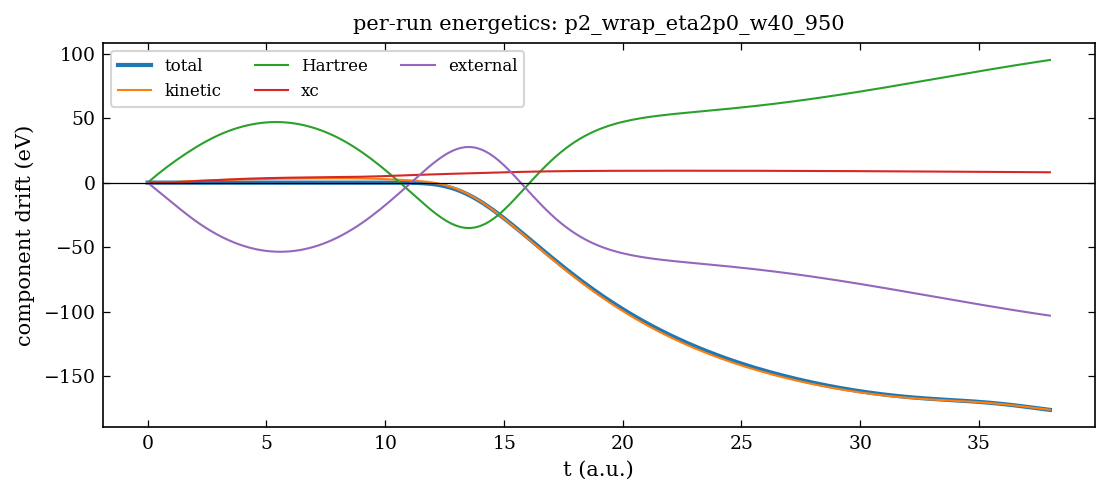

In [8]:
comps = [("energy_kinetic", "kinetic"), ("energy_hartree", "Hartree"),
         ("energy_xc", "xc"), ("energy_external", "external")]
df = pd.read_csv(f"{BASE}/p2_wrap_eta2p0_w40_950/raw/observables/observables.csv")
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for c, lbl in [("energy_total", "total")] + comps:
    ax.plot(df.time_au, (df[c] - df[c].iloc[0]) * HA_EV, label=lbl,
            lw=2 if c == "energy_total" else 1)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("component drift (eV)")
ax.set_title("per-run energetics: p2_wrap_eta2p0_w40_950")
ax.legend(fontsize=8, ncol=3)
fig.tight_layout(); fig.savefig("figs/p2_wrap_eta2p0_w40_950_energetics.png", dpi=150); plt.show()


## Summary table (all six runs, locked metrics)

Recomputed from the raw CSVs by the cells above; matches `hypotheses/pbc_open_z/comparison.md` (auto-written by the orchestrator).

In [9]:
rows = []
for p2, p3 in [('p2_two_eta0p2_700', 'run01_baseline_two_eta0p2'), ('p2_two_eta1p0_950', 'run06_poscontrol_eta1p0_950'), ('p2_wrap_eta2p0_w40_950', 'run11_wrap_eta2p0_w40_950')]:
    for tag, run in (("p2", p2), ("p3", p3)):
        t, e = series(run)
        m = metrics(t, e)
        rows.append((p2.replace("p2_", ""), tag, m["t_min"], m["drain"],
                     m["rise"], m["excursion"]))
summ = pd.DataFrame(rows, columns=["pair", "conv", "t_min_au", "drain_eV",
                                   "rise_eV", "excursion_eV"])
summ.round(3)


,pair,conv,t_min_au,drain_eV,rise_eV,excursion_eV
0,two_eta0700,p2,21.8,-22.393,23.739,1.346
1,two_eta0700,p3,21.6,-23.385,23.495,0.110
2,two_eta1p0_950,p2,28.0,-137.574,174.131,37.623
3,two_eta1p0_950,p3,27.8,-138.051,169.324,31.272
4,wrap_eta2p0_w40_950,p2,38.0,-176.309,0.000,0.002
5,wrap_eta2p0_w40_950,p3,38.0,-178.309,0.000,0.000


## Takeaway

- **Arm B is refuted as the cause/clock of the oscillation.** With open-z electrostatics (matched p2 GS) the drain-then-rise morphology is fully reproduced and the turn time barely moves: t_min = 21.8 vs 21.6 and 28.0 vs 27.8 a.u. (Δ ≈ 0.2 a.u., far below any period-relevant scale). The wrap winner stays turn-free to t = 38 at both periodicities.
- **Electrostatic periodicity modulates the amplitude — in the *worse* direction at p2:** rise 23.7 vs 23.5 eV (weak η) and 174 vs 169 eV (η=−1); excursion above zero 1.3 vs 0.11 eV and 38 vs 31 eV. Differences exceed the 0.1 eV noise floor, so p2 ≠ p3 — but as an amplitude modulation, not a mechanism switch.
- **The static GS tail is exonerated too:** the p2 GS tail under the CAP is ~6 orders smaller, yet the oscillation is unchanged — the feeder is *dynamically spilled* slow density, as diagnosed.
- **Open next:** the oscillation's clock. Candidates: Arm A recirculation (test: period vs L_z scaling) or the slow-spill arrival time at the CAP (consistent with t_min tracking CAP config but not Poisson convention).